# The function to launch the algorithm is at the end of the notebook

# Preparation

Importer les librairies necessaires

In [1]:
import networkx as nx
import json
import random
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Transformer la solution en un graph simple

In [2]:
# Charger le JSON du graphe 
input_path = r"C:\Users\DeLL\Documents\IFIE 2\Projet recherche\coin codage\graph_commune_adjacence.json"
with open(input_path, 'r', encoding='utf-8') as f:
    graph_data = json.load(f)

G_orig = nx.node_link_graph(graph_data, edges="links") # Recréer le graphe NetworkX 

G_clean = G_orig.copy()  #  Creer une copie du graphe original

for node_id, data in G_clean.nodes(data=True): #enlever district et neighbors
    data.pop('district', None) 
    data.pop('neighbors', None)  

print(f"Nodes: {G_clean .number_of_nodes()}")
print(f"Sample Node Attributes: {G_clean .nodes['COMMUNE_0000000009757480']}")

Nodes: 100
Sample Node Attributes: {'population': 1593, 'centroid': [630916.2946971117, 6357107.109014952]}


# Les fonctions

Bloc 01: Generer les n solutions
 
Génère N solutions valides via croissance de régions.

Prend nodes_order en argument pour garantir la cohérence.


In [3]:
def generate_initial_population(graph, nodes_order, pop_size, n_districts, max_communes):
    population = []
    nodes = list(graph.nodes()) 
    
    for _ in range(pop_size):
        solution = {} # Dans ce dictionnaire va etre stocker chaque commune et le district au quel elle appartient
        unassigned = set(nodes) # Au debut tous les commmunes n'appartienent pas un district
        
        # Graines
        # On selectionne des seeds aleoratoirement (meme nombre que celui des districts).
        # On etablit les dictionnaires preleminaires
        seeds = random.sample(nodes, n_districts)
        boundaries = {d: set() for d in range(1, n_districts + 1)} # Va servir pour definir les frontieres de chaque district
        sizes = {d: 0 for d in range(1, n_districts + 1)} # Contient la taille de chaque district
        
        for idx, seed in enumerate(seeds):
            d_id = idx + 1
            solution[seed] = d_id # On colle chaque seed a un district pour faire l'elargissement apres
            unassigned.remove(seed)
            sizes[d_id] += 1
            for n in graph.neighbors(seed):
                if n in unassigned: boundaries[d_id].add(n) # On ajoute tous les voisins du seed qui ne sont pas deja des seed au dictionnaire des frontieres
        
        # Croissance
        active_districts = list(range(1, n_districts + 1)) # Signifie les district qui font encore parti du jeux
        while unassigned and active_districts:
            random.shuffle(active_districts)
            to_remove = []
            
            for d_id in active_districts:
                if sizes[d_id] >= max_communes or not boundaries[d_id]:
                    to_remove.append(d_id) # si un district a atteint sa taille maximale ou qu'il n'a plus de commune dispo sur ces frontieres, il est ajoute a la liste des districts a virer du jeux
                    continue
                
                candidates = list(boundaries[d_id])
                chosen = random.choice(candidates) # On choisis aleoratoirement une commune qui se trouve sur les frontieres
                
                if chosen not in unassigned: # On verifie d'abords qu'elle n'apartient pas deja a un autre district
                    boundaries[d_id].remove(chosen)
                    continue
                
                # On met a jour les indices, les tailles...
                solution[chosen] = d_id
                unassigned.remove(chosen) 
                sizes[d_id] += 1
                boundaries[d_id].remove(chosen)
                
                for n in graph.neighbors(chosen):
                    if n in unassigned: boundaries[d_id].add(n) # On ajoute les voisins de la nouvelle commune aux frontieres du district
            
            for d in to_remove:
                if d in active_districts: active_districts.remove(d) # On enleve les districts qui ne peuvent plus evoluer
        
        # les orphelins
        # Il se peut que des communes se trouvent dans auncune district
        for node in list(unassigned):
            neighbors = [n for n in graph.neighbors(node) if n in solution] # On cherche les voisins qui appartiennent deja a un district
            if neighbors:
                target = solution[random.choice(neighbors)]
                solution[node] = target # On l'attribue au district de l'un des voisin
            else:
                solution[node] = random.randint(1, n_districts) # au pir des cas, on attribue la commune a un district quelconque, meme si elle est deconnecte, l'operateur de reparation va resoudre cela apres
        
        # Conversion dictionnaire -> chromosome (liste)
        chromosome = [solution[n] for n in nodes_order] # On veut que le remplissage des chromosome suit toujours le meme ordre, comme ca chaque position dans la liste correspond a une commune precise
        population.append(chromosome)
        
    return population

Crossover

SOUS-FONCTION : Notation d'un district unique

Calcule un score de pénalité pour un seul district.
Plus le score est BAS, meilleur est le district.
Critères :
1. Ecart par rapport à la population idéale.
2. Compacité (Inertie : somme des distances au centre).
    

In [4]:
def score_single_district(graph, nodes_in_district, ideal_pop_avg,poids_pop ,poids_comp):
    if not nodes_in_district:
        return float('inf') # District vide = Très mauvais

    # Calcul Population & Centroid 
    total_pop = 0
    sum_x, sum_y = 0, 0
    coords_list = []

    for node in nodes_in_district:
        data = graph.nodes[node]
        p = data.get('population', 0)
        c = data.get('centroid', [0, 0])
        
        total_pop += p
        sum_x += c[0] * p  # Pondéré par la pop pour trouver le centre de gravité
        sum_y += c[1] * p
        coords_list.append((c, p))

    # Centre de gravité du district
    if total_pop > 0:
        center_x = sum_x / total_pop
        center_y = sum_y / total_pop
    else:
        return float('inf')

    #  Score Population (Ecart absolu) 
    # Combien de personnes en trop ou en moins par rapport à l'idéal ?
    pop_penalty = abs(total_pop - ideal_pop_avg)

    # Score Compacité (Inertie)
    # Somme des distances de chaque commune vers le centre du district
    inertia = 0
    for (x, y), p in coords_list:
        # Distance Euclidienne
        dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        inertia += dist 

    # Score Final Pondéré
        return (poids_pop * pop_penalty) + (poids_comp* inertia)



FONCTION PRINCIPALE : Le Crossover
1. Trouve le meilleur district de A et l'injecte dans B (Enfant 1).
2. Trouve le meilleur district de B et l'injecte dans A (Enfant 2).

In [5]:
def crossover_smart_exchange(parent_A, parent_B, graph, nodes_order, n_districts,poids_pop,poids_comp):
    # Calcul de la moyenne idéale (Population Totale / N Districts)
    # On le fait une fois pour toutes
    total_map_pop = sum(d['population'] for n, d in graph.nodes(data=True))
    ideal_avg = total_map_pop / n_districts

    #  ETAPE 1 : Identifier le Champion de A
    best_district_A_id = -1
    best_score_A = float('inf')

    for d_id in range(1, n_districts + 1):
        # Trouver les noeuds qui appartiennent à ce district
        indices = [i for i, x in enumerate(parent_A) if x == d_id]
        nodes = [nodes_order[i] for i in indices]
        
        # Noter le district
        score = score_single_district(graph, nodes, ideal_avg,poids_pop,poids_comp)
        
        if score < best_score_A:
            best_score_A = score
            best_district_A_id = d_id

    #ETAPE 2 : Identifier le Champion de B
    best_district_B_id = -1
    best_score_B = float('inf')

    for d_id in range(1, n_districts + 1):
        indices = [i for i, x in enumerate(parent_B) if x == d_id]
        nodes = [nodes_order[i] for i in indices]
        
        score = score_single_district(graph, nodes, ideal_avg,poids_pop,poids_comp)
        
        if score < best_score_B:
            best_score_B = score
            best_district_B_id = d_id

    #ETAPE 3 : Injection (Création des enfants)
    
    # Enfant 1 : Base B + Champion A
    child_1 = list(parent_B) 
    # On récupère les indices des nœuds du champion A
    indices_champ_A = [i for i, x in enumerate(parent_A) if x == best_district_A_id]
    # On écrase ces positions dans l'enfant
    for idx in indices_champ_A:
        child_1[idx] = best_district_A_id

    # Enfant 2 : Base A + Champion B
    child_2 = list(parent_A)
    indices_champ_B = [i for i, x in enumerate(parent_B) if x == best_district_B_id]
    for idx in indices_champ_B:
        child_2[idx] = best_district_B_id

    return child_1, child_2

Mutation

Parcourt le génome et modifie UNIQUEMENT les noeuds situés à la frontière.
Un noeud frontière prend l'identité d'un de ses voisins d'un autre district.

Args:
    chromosome: La liste des IDs de districts.
    graph: Le graphe NetworkX.
    nodes_order: La liste de référence des IDs de noeuds.
    mutation_rate: Probabilité de mutation par noeud (ex: 0.05 pour 5%).


In [6]:
def mutation_boundary_smoothing(chromosome, graph, nodes_order, mutation_rate=0.05):
    # Créer un dictionnaire de correspondance ID -> Index
    # Cela permet de trouver instantanément le district d'un voisin sans parcourir toute la liste.
    # (Idéalement, calculez ceci UNE fois au début du programme et passez-le en argument)
    node_to_idx = {node: i for i, node in enumerate(nodes_order)}
    
    # On parcourt chaque gène (chaque commune)
    for i in range(len(chromosome)):
        
        #Test de probabilité
        if random.random() > mutation_rate:
            continue
            
        current_node = nodes_order[i]
        current_district = chromosome[i]
        
        #Récupérer les voisins
        neighbors = list(graph.neighbors(current_node))
        if not neighbors:
            continue
            
        # Analyser l'entourage
        # On cherche s'il y a des districts DIFFÉRENTS autour
        neighbor_districts = []
        possible_targets = []
        
        for neighbor in neighbors:
            # Grâce au dictionnaire, c'est instantané
            n_idx = node_to_idx[neighbor]
            n_dist = chromosome[n_idx]
            
            if n_dist != current_district:
                possible_targets.append(n_dist)
        
        # Action de Mutation
        # Si 'possible_targets' n'est pas vide, c'est que nous sommes sur une FRONTIÈRE.
        if possible_targets:
            # On adopte le district d'un des voisins étrangers
            # Cela lisse la frontière en déplaçant la ligne d'un cran.
            new_district = random.choice(possible_targets)
            chromosome[i] = new_district
            
    return chromosome

Repair operator

Opérateur de Réparation en 3 étapes :
1. Contiguïté : Fusionne les îles isolées avec le voisin majoritaire.
2. Taille : Dissout les districts trop petits (< min_nodes).
3. Nombre : Force la fusion des districts les plus petits si Total > max_districts.


In [7]:
def repair_solution_full(chromosome, graph, nodes_order, min_nodes, max_districts):

    
    #  PREPARATION 
    # On travaille avec un dictionnaire pour accès rapide 
    # node_id -> district_id
    sol_dict = {node: chromosome[i] for i, node in enumerate(nodes_order)}
    
    # Fonction pour absorber un groupe de noeuds dans le meilleur voisin
    def absorb_nodes(nodes_to_absorb):
        # Trouver tous les voisins externes à ce groupe
        external_neighbors_districts = []
        for node in nodes_to_absorb:
            for neighbor in graph.neighbors(node):
                if neighbor not in nodes_to_absorb: # Si le voisin est dehors
                    # On note le district de ce voisin
                    external_neighbors_districts.append(sol_dict[neighbor])
        
        if external_neighbors_districts:
            # Vote majoritaire : On rejoint le district le plus présent autour
            target_district = Counter(external_neighbors_districts).most_common(1)[0][0]
            # Application
            for node in nodes_to_absorb:
                sol_dict[node] = target_district
            return True # Changement effectué
        return False # Pas de voisins (cas rare d'ile totale)


    # ETAPE 1 : CORRECTION DES ENCLAVES (Contiguïté).
    # On vérifie chaque district. S'il est en plusieurs morceaux, 
    # on garde le plus gros et on dissout les petits.
    
    unique_ids = set(sol_dict.values())
    
    for d_id in list(unique_ids):
        nodes_in_d = [n for n, d in sol_dict.items() if d == d_id] # Récupérer tous les noeuds de ce district
        
        
        sub = graph.subgraph(nodes_in_d) # Créer le sous-graphe pour vérifier la connexité
        
        if not nx.is_connected(sub):
            # Récupérer les composants (îles), triés du plus grand au plus petit
            components = sorted(nx.connected_components(sub), key=len, reverse=True)
            
            # Le premier composant est le "Continent", on le garde.
            # Tous les autres (components[1:]) sont des enclaves à supprimer.
            for island in components[1:]:
                absorb_nodes(island)

    
    # ETAPE 2 : CORRECTION DE LA TAILLE (Micro-Districts)
    # On boucle tant qu'il y a des changements, car absorber un petit district.
    # pourrait théoriquement en isoler un autre (rare mais possible).
    
    has_changed = True
    while has_changed:
        has_changed = False
        
        # Compter la taille de chaque district
        counts = Counter(sol_dict.values())
        
        # Identifier les districts trop petits
        small_districts = [d for d, c in counts.items() if c < min_nodes]
        
        for d_id in small_districts:
            nodes_in_d = [n for n, d in sol_dict.items() if d == d_id]
            # Dissoudre tout le district
            if absorb_nodes(nodes_in_d):
                has_changed = True
    
    
    # ETAPE 3 : CORRECTION DU NOMBRE DE DISTRICTS
    # Si on a plus de districts que permis, on supprime les plus petits.
    # jusqu'à atteindre la limite.
    
    current_districts = set(sol_dict.values())
    
    while len(current_districts) > max_districts:
        # Trouver le plus petit district actuel
        counts = Counter(sol_dict.values())
        smallest_district = min(counts, key=counts.get)
        
        # Récupérer ses noeuds
        nodes_in_d = [n for n, d in sol_dict.items() if d == smallest_district]
        
        # L'absorber dans ses voisins
        absorb_nodes(nodes_in_d)
        
        # Mettre à jour la liste des districts présents
        current_districts = set(sol_dict.values())

    # On remet le dictionnaire sous forme de liste (chromosome)
    return [sol_dict[n] for n in nodes_order]

fitness function

In [8]:

def calculate_fitness_final(chromosome, graph, nodes_order, target_districts, poids_pop, poids_comp):
    
    #DECODAGE & REGROUPEMENT
    clusters = {i: [] for i in range(1, target_districts + 1)}
    
    for idx, d_id in enumerate(chromosome):
        if d_id not in clusters: d_id = 1 
        node_id = nodes_order[idx]
        clusters[d_id].append(node_id)

    #Connectivité
    for d_id, nodes in clusters.items():
        if not nodes: continue
        
        # Création d'une vue
        sub = graph.subgraph(nodes)
        
        # ICI c'est l'appel à la librairie networkx
        if not nx.is_connected(sub):
            return float('inf') 

    #SCORE POPULATION
    pop_values = []
    for d_id, nodes in clusters.items():
        d_pop = sum(graph.nodes[n].get('population', 0) for n in nodes)
        pop_values.append(d_pop)
    
    score_pop = np.std(pop_values)

    #SCORE COMPACITÉ
    total_inertia = 0.0
    
    for d_id, nodes in clusters.items():
        if not nodes: continue
        
        node_data = [] 
        sum_x, sum_y, tot_p = 0, 0, 0
        
        for n in nodes:
            coords = graph.nodes[n].get('centroid', [0, 0])
            pop = graph.nodes[n].get('population', 1)
            
            sum_x += coords[0] * pop
            sum_y += coords[1] * pop
            tot_p += pop
            node_data.append((coords, pop))
            
        if tot_p > 0:
            center_x = sum_x / tot_p
            center_y = sum_y / tot_p
        else:
            center_x, center_y = 0, 0
            
        dist_sum = 0
        
    
        for (cx, cy), pop in node_data:
            dist = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
            dist_sum += dist * pop
            
        total_inertia += dist_sum

    return (poids_pop* score_pop) + (poids_comp * total_inertia)

Remplacement 
Fusionne Parents et Enfants, trie par fitness, et garde les meilleurs.
Gère le remplacement pour la génération suivante.


In [9]:
def selection_elitist_merge(parents, offspring, fitness_parents, fitness_offspring, pop_size):
    
    #Création du Grand Pool
    pool = list(zip(parents, fitness_parents)) + list(zip(offspring, fitness_offspring)) # On associe chaque chromosome à son score pour ne pas les perdre lors du tri. # Structure : [(chromosome_A, score_A), (chromosome_B, score_B), ...]
    
    #Tri par Fitness (Minimisation)
    pool.sort(key=lambda x: x[1]) # On veut les scores les plus BAS en premier. Les solutions invalides (fitness = inf) seront rejetées à la fin de la liste.
    
    # DEDUPLICATION (Diversité)
    # Si on a 50 fois la même solution parfaite, l'algo va stagner.
    # On peut filtrer pour ne garder que des solutions UNIQUES (basé sur le score ou le contenu).
    unique_pool = []
    seen_scores = set()
    
    for ind, fit in pool:
        # On arrondit le score pour éviter les micro-différences de float
        rounded_fit = round(fit, 6)
        
        # Si on n'a pas encore vu ce score précis OU si c'est une solution infinie (on rejette)
        if rounded_fit not in seen_scores and fit != float('inf'):
            unique_pool.append((ind, fit))
            seen_scores.add(rounded_fit)
            
        # Si on a assez de monde, on arrête
        if len(unique_pool) >= pop_size:
            break
            
    # Si la déduplication a été trop violente et qu'on manque de monde, 
    # on complète avec les doublons qu'on avait ignorés (sauf les infinis)
    if len(unique_pool) < pop_size:
        remaining_slots = pop_size - len(unique_pool)
        for ind, fit in pool:
            if fit == float('inf'): continue # On ne veut vraiment pas des invalides
            
            # Si cette solution n'est pas déjà dans unique_pool (par référence d'objet)
            if not any(ind is x[0] for x in unique_pool):
                unique_pool.append((ind, fit))
                if len(unique_pool) >= pop_size:
                    break
    
    #Sélection finale 
    # On ne garde que le nombre exact requis
    best_survivors = unique_pool[:pop_size]
    
    #Séparation pour le retour
    new_population = [x[0] for x in best_survivors]
    new_fitness = [x[1] for x in best_survivors]
    
    return new_population, new_fitness

ALGORITHME GÉNÉTIQUE PRINCIPAL

In [10]:
def run_partitioning_algorithm(target_graph, num_districts, pop_size, max_generations, poids_pop, poids_comp, coef_min_com, coef_max_com, mutation_rate):

    print(f"--- Démarrage de l'Algorithme pour {num_districts} districts ---")
    start_time = time.time()

    # --- CONSTANTES & RÉFÉRENCE ---
    NODES_ORDER = list(target_graph.nodes())
    
    # Paramètres dérivés
    total_pop = sum(d.get('population', 0) for n, d in target_graph.nodes(data=True))
    
    # Contraintes
    MIN_NODES = int((len(NODES_ORDER) / num_districts) * coef_min_com) 
    MAX_COMMUNES_INIT = int((len(NODES_ORDER) / num_districts) * coef_max_com)

    # --- INITIALISATION ---
    print("-> Génération de la population initiale")
    population = generate_initial_population(
        graph=target_graph, 
        nodes_order=NODES_ORDER, 
        pop_size=pop_size, 
        n_districts=num_districts, 
        max_communes=MAX_COMMUNES_INIT
    )

    # Evaluation Initiale
    fitness_scores = []
    for ind in population:
        ind = repair_solution_full(ind, target_graph, NODES_ORDER, MIN_NODES, num_districts)
        fit = calculate_fitness_final(ind, target_graph, NODES_ORDER, num_districts, poids_pop, poids_comp)
        fitness_scores.append(fit)

    # Tracking
    best_global_fitness = float('inf')
    best_global_solution = None

    # --- BOUCLE D'ÉVOLUTION ---
    for gen in range(1, max_generations + 1):
        
        # 1. REPRODUCTION 
        offspring = []
        parents_pool = list(population)
        random.shuffle(parents_pool)
        
        for i in range(0, len(parents_pool) - 1, 2):
            p1 = parents_pool[i]
            p2 = parents_pool[i+1]
            c1, c2 = crossover_smart_exchange(p1, p2, target_graph, NODES_ORDER, num_districts, poids_pop, poids_pop)
            offspring.extend([c1, c2])
            
        if len(parents_pool) % 2 != 0:
            offspring.append(parents_pool[-1][:])

        # 2. MUTATION & ÉVALUATION
        final_offspring = []
        offspring_fitnesses = []
        
        for child in offspring:
            child = mutation_boundary_smoothing(child, target_graph, NODES_ORDER, mutation_rate)
            child = repair_solution_full(child, target_graph, NODES_ORDER, MIN_NODES, num_districts)
            fit = calculate_fitness_final(child, target_graph, NODES_ORDER, num_districts, poids_pop, poids_comp)
            
            final_offspring.append(child)
            offspring_fitnesses.append(fit)

        # 3. SÉLECTION
        population, fitness_scores = selection_elitist_merge(
            parents=population,
            offspring=final_offspring,
            fitness_parents=fitness_scores,
            fitness_offspring=offspring_fitnesses,
            pop_size=pop_size
        )
        
        # 4. MONITORING
        current_best = fitness_scores[0]
        if current_best < best_global_fitness:
            best_global_fitness = current_best
            best_global_solution = population[0][:]
            print(f"Gen {gen} | Nouveau record : {best_global_fitness:.4f}")
        elif gen % 10 == 0:
            print(f"Gen {gen} | Best: {current_best:.4f}")

    # --- FIN & ANALYSE ---
    end_time = time.time()
    print(f"\n--- Terminé en {end_time - start_time:.2f} secondes ---")
    print(f"Meilleur Score Final : {best_global_fitness}")
    
    final_dict = {node: best_global_solution[i] for i, node in enumerate(NODES_ORDER)}
    
    
    # C'EST ICI QUE J'AI CORRIGÉ LE BUG "KeyError: 13"
    
    
    # On initialise les dictionnaires vides pour être sûr de tout accepter
    stats = {
        "populations": {},
        "centroids": {},
        "node_counts": {},
        "dist_variance": {}
    }
    
    # 1. Cumul Pop et Coordonnées (Dynamique)
    for i, node_id in enumerate(NODES_ORDER):
        d_id = best_global_solution[i]
        
        # SÉCURITÉ : Si l'ID n'existe pas encore (ex: ID 13), on le crée
        if d_id not in stats["populations"]:
            stats["populations"][d_id] = 0
            stats["centroids"][d_id] = [0.0, 0.0]
            stats["node_counts"][d_id] = 0
        
        # Pop
        pop = target_graph.nodes[node_id].get('population', 0)
        stats["populations"][d_id] += pop
        
        # Coords
        if 'centroid' in target_graph.nodes[node_id]:
            coord = target_graph.nodes[node_id]['centroid']
            stats["centroids"][d_id][0] += coord[0]
            stats["centroids"][d_id][1] += coord[1]
            stats["node_counts"][d_id] += 1
            
    # 2. Finalisation des Centroïdes
    # On itère sur les clés qui existent vraiment (ex: 0 à 12, ou 1 à 13)
    found_districts = list(stats["populations"].keys())
    
    for d_id in found_districts:
        count = stats["node_counts"][d_id]
        if count > 0:
            stats["centroids"][d_id][0] /= count
            stats["centroids"][d_id][1] /= count
            
    # 3. Calcul de l'écart (Distance moyenne au centroïde)
    district_distances = {d: [] for d in found_districts}
    
    for i, node_id in enumerate(NODES_ORDER):
        d_id = best_global_solution[i]
        if 'centroid' in target_graph.nodes[node_id]:
            n_x, n_y = target_graph.nodes[node_id]['centroid']
            c_x, c_y = stats["centroids"][d_id]
            dist = np.sqrt((n_x - c_x)**2 + (n_y - c_y)**2)
            district_distances[d_id].append(dist)
            
    for d_id in found_districts:
        if district_distances[d_id]:
            mean_dist = np.mean(district_distances[d_id])
            std_dist = np.std(district_distances[d_id])
            stats["dist_variance"][d_id] = (mean_dist, std_dist)
        else:
            stats["dist_variance"][d_id] = (0, 0)

    return final_dict, best_global_fitness, stats

Visulatisation

In [11]:
def visualiser_partition_finale(graph, partition_dict, params_algo, stats, title):
    
    # 1. Extraire les positions (Centroids)
    try:
        # On essaie de récupérer les positions géographiques réelles
        pos = {n: np.array(graph.nodes[n]['centroid']) for n in graph.nodes()}
    except KeyError:
        print("ERREUR : Pas de coordonnées 'centroid'. Utilisation layout aléatoire.")
        pos = nx.spring_layout(graph)

    # 2. GESTION DES COULEURS (La source de vérité)
    # On identifie tous les districts uniques (ex: 0, 1, 2, 5...)
    unique_districts = sorted(list(set(partition_dict.values())))
    
    # On choisit la palette
    cmap = plt.get_cmap("tab20")
    
    # On associe une couleur fixe à chaque ID de district.
    # C'est ce dictionnaire qui garantit que Carte == Légende.
    district_color_map = {d_id: cmap(d_id % 20) for d_id in unique_districts}
    
    # On prépare la liste des couleurs pour chaque nœud individuel
    node_list = list(graph.nodes())
    node_colors_draw = [district_color_map[partition_dict[n]] for n in node_list]

    # 3. Préparation des données de Population
    # Si on a reçu le dictionnaire 'stats' de l'algo, on l'utilise (plus précis)
    if stats and "populations" in stats:
        pops_data = stats["populations"]
    else:
        # Sinon on recalcule à la main
        pops_data = {}
        for n in node_list:
            d_id = partition_dict[n]
            pop = graph.nodes[n].get('population', 0)
            pops_data[d_id] = pops_data.get(d_id, 0) + pop

    # 4. Config Figure
    plt.figure(figsize=(16, 12)) 
    ax = plt.gca()
    plt.title(title, fontsize=20, fontweight='bold', color='#2c3e50', pad=20)

    # 5. Dessin du Graphe
    # Arêtes (Fond de carte)
    nx.draw_networkx_edges(graph, pos, alpha=1, edge_color="#000000", width=0.8)
    
    # Nœuds (Communes)
    nx.draw_networkx_nodes(
        graph, pos,
        nodelist=node_list,
        node_color=node_colors_draw, # <--- On utilise nos couleurs fixées manuellement
        node_size=450,
        alpha=1,
        edgecolors='black',
        linewidths=1
    )

    # 6. Étiquettes sur la carte (D0, D1...)
    # On calcule le centre visuel de chaque district
    district_coords_sum = {}
    district_counts = {}
    
    for n, coords in pos.items():
        d_id = partition_dict[n]
        if d_id not in district_coords_sum:
            district_coords_sum[d_id] = np.array([0.0, 0.0])
            district_counts[d_id] = 0
        district_coords_sum[d_id] += coords
        district_counts[d_id] += 1
        
    for d_id, sum_coords in district_coords_sum.items():
        if district_counts[d_id] > 0:
            avg_coords = sum_coords / district_counts[d_id]
            
            # Astuce design : couleur du texte adaptée au fond (optionnel, ici noir ou blanc)
            bg_color = district_color_map[d_id]
            # Formule de luminance pour savoir si le fond est sombre
            lum = 0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2]
            text_col = 'white' if lum < 0.5 else 'black'

            plt.text(
                avg_coords[0], avg_coords[1], 
                f"D{d_id}", 
                fontsize=11, fontweight='bold', color=text_col,
                ha='center', va='center',
                # Le fond de l'étiquette a la même couleur que le district
                bbox=dict(facecolor=district_color_map[d_id], alpha=0.8, edgecolor='white', pad=2)
            )

    # 7. INFOBOX (Gauche)
    info_text = (
        f"Mutation Rate : {params_algo.get('mutation_rate', '?')}\n"
        f"Coeff. Pop    : {params_algo.get('poids_pop', '?')}\n"
        f"Coeff. Comp   : {params_algo.get('poids_comp', '?')}\n"
        f"------------------\n"
        f"Min Communes  : {params_algo.get('min_nodes', '?')}\n"
        f"Max Communes  : {params_algo.get('max_nodes', '?')}"
    )
    plt.text(0.02, 0.98, info_text,
             transform=ax.transAxes, fontsize=11, verticalalignment='top', family='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#ecf0f1", alpha=0.9, edgecolor='#bdc3c7'))

    # 8. LÉGENDE (Droite) : District + Population
    legend_patches = []
    sorted_districts = sorted(unique_districts)
    
    for d_id in sorted_districts:
        # Couleur EXACTE (celle du dico)
        color = district_color_map[d_id] 
        
        # Texte demandé : "Dist X : Y hab"
        pop = pops_data.get(d_id, 0)
        label = f"Dist {d_id} : {int(pop):,} hab".replace(",", " ") # Espace comme séparateur
        
        # On crée le patch AVEC la couleur, sinon la légende est inutile
        patch = mpatches.Patch(color=color, label=label)
        legend_patches.append(patch)

    plt.legend(
        handles=legend_patches, 
        title="Populations",
        loc='center left', 
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#bdc3c7'
    )

    # 9. Finalisation et Sauvegarde
    plt.axis('off')
    ax.set_aspect('equal')
    plt.tight_layout()
    
    filename = "resultat_final_HD_coherent.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight', transparent=True)
    print(f" Image sauvegardée : {filename}")
    
    plt.show()

# Fonction d'execution finale

In [12]:
def genetic_with_vis(target_graph, num_districts, pop_size, max_generations, poids_pop, poids_comp, coef_min_com, coef_max_com, mutation_rate, title):
    
    # 1. Lancement de l'algorithme
    # On récupère désormais 3 valeurs (partition, score, et les stats détaillées)
    best_partition, score, stats = run_partitioning_algorithm(
        target_graph, num_districts, pop_size, max_generations,
        poids_pop, poids_comp, coef_min_com, coef_max_com, mutation_rate
    )

    print(f"Meilleure fitness obtenue : {score}")

    # 2. Préparation des paramètres pour l'affichage (InfoBox)
    # On recalcule min/max nodes juste pour l'affichage
    total_nodes = len(target_graph.nodes())
    min_nodes = int((total_nodes / num_districts) * coef_min_com)
    max_nodes = int((total_nodes / num_districts) * coef_max_com)

    params_pour_visu = {
        'mutation_rate': mutation_rate,
        'poids_pop': poids_pop,
        'poids_comp': poids_comp,
        'min_nodes': min_nodes,
        'max_nodes': max_nodes
    }

    # 3. Lancement de la visualisation
    # On passe bien 'params_pour_visu' en 3ème argument
    visualiser_partition_finale(target_graph, best_partition, params_pour_visu,stats, title)

--- Démarrage de l'Algorithme pour 13 districts ---
-> Génération de la population initiale
Gen 1 | Nouveau record : 3151195.1445
Gen 2 | Nouveau record : 3080394.9015
Gen 8 | Nouveau record : 3057530.2211
Gen 10 | Nouveau record : 2845085.9049

--- Terminé en 0.17 secondes ---
Meilleur Score Final : 2845085.9048679373
Meilleure fitness obtenue : 2845085.9048679373
 Image sauvegardée : resultat_final_HD_coherent.png


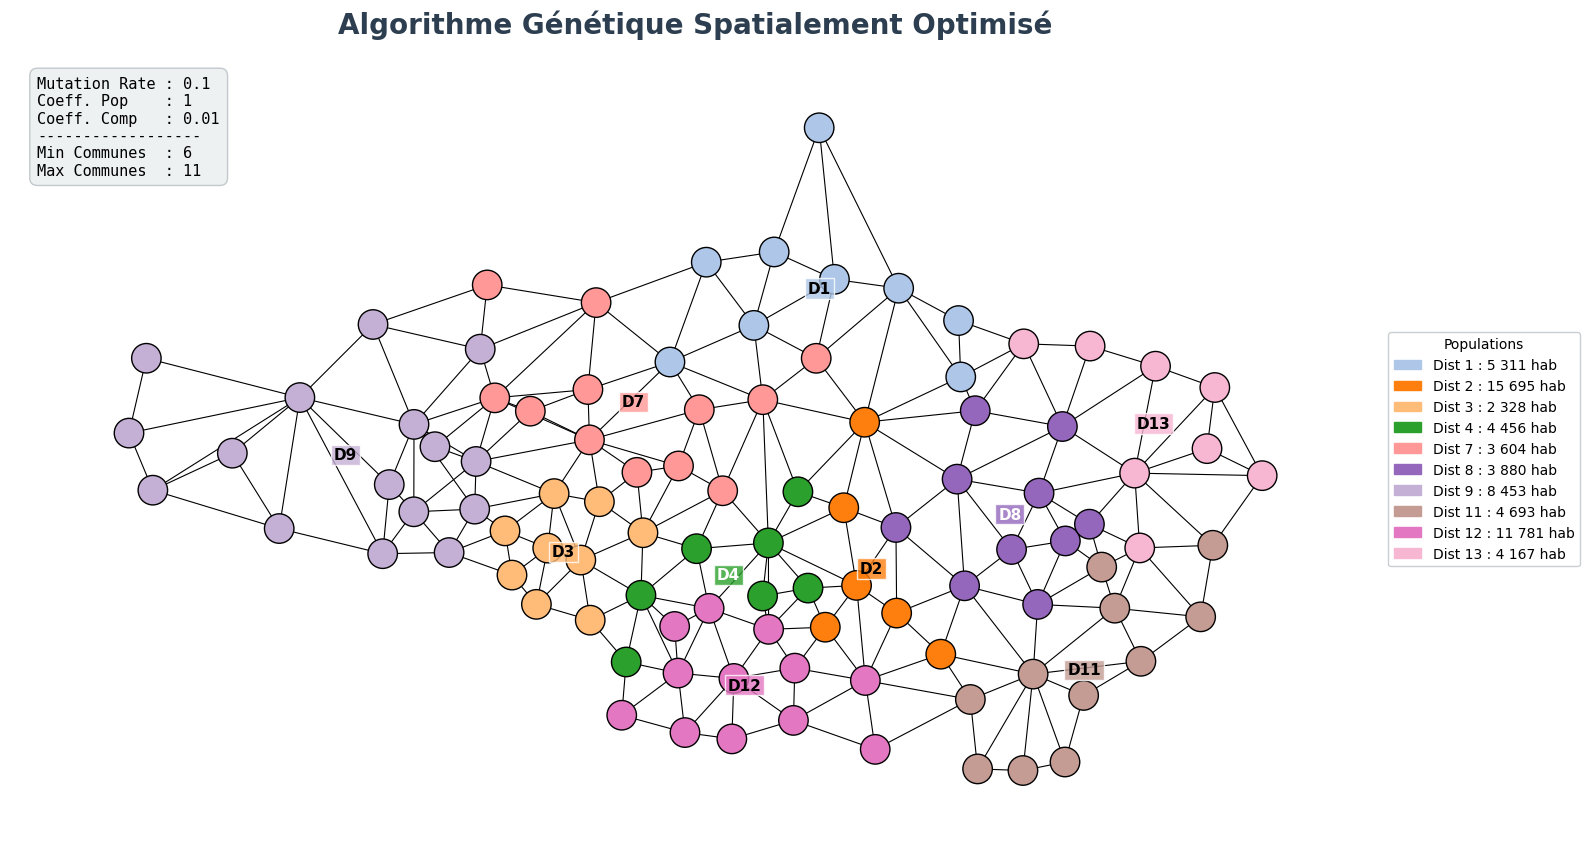

In [13]:
genetic_with_vis(    target_graph=G_clean,
    num_districts=13,
    pop_size=10,     
    max_generations=10,
    poids_pop=1,
    poids_comp=0.01,
    coef_min_com=0.8,
    coef_max_com=1.5,
    mutation_rate=0.1,
    title="Algorithme Génétique Spatialement Optimisé"
)